In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score

In [2]:
df = pd.read_csv("/content/heart.csv")

print(df.head())
print(df.info())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age    

In [19]:
print(df.columns)

Index(['age', 'sex', 'chestpaintype', 'restingbp', 'cholesterol', 'fastingbs',
       'restingecg', 'maxhr', 'exerciseangina', 'oldpeak', 'st_slope',
       'heartdisease'],
      dtype='object')


In [20]:
df.columns = df.columns.str.lower()

print(df.columns)

Index(['age', 'sex', 'chestpaintype', 'restingbp', 'cholesterol', 'fastingbs',
       'restingecg', 'maxhr', 'exerciseangina', 'oldpeak', 'st_slope',
       'heartdisease'],
      dtype='object')


In [21]:
categorical_cols = ['sex','chestpaintype','restingecg','exerciseangina','st_slope']

df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print(df.head())

   age  restingbp  cholesterol  fastingbs  maxhr  oldpeak  heartdisease  \
0   40        140          289          0    172      0.0             0   
1   49        160          180          0    156      1.0             1   
2   37        130          283          0     98      0.0             0   
3   48        138          214          0    108      1.5             1   
4   54        150          195          0    122      0.0             0   

   sex_M  chestpaintype_ATA  chestpaintype_NAP  chestpaintype_TA  \
0   True               True              False             False   
1  False              False               True             False   
2   True               True              False             False   
3  False              False              False             False   
4   True              False               True             False   

   restingecg_Normal  restingecg_ST  exerciseangina_Y  st_slope_Flat  \
0               True          False             False          False

In [22]:
X = df.drop("heartdisease", axis=1)

y = df["heartdisease"]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [26]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

lr_prob = lr.predict_proba(X_test_scaled)[:,1]

print("Accuracy:", accuracy_score(y_test, lr_pred))

print("F1 Score:", f1_score(y_test, lr_pred))

print("ROC AUC:", roc_auc_score(y_test, lr_prob))

Accuracy: 0.8532608695652174
F1 Score: 0.8695652173913043
ROC AUC: 0.9266901322976089


In [27]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

rf_prob = rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, rf_pred))

print("F1 Score:", f1_score(y_test, rf_pred))

print("ROC AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.8641304347826086
F1 Score: 0.8826291079812206
ROC AUC: 0.9359752397135576


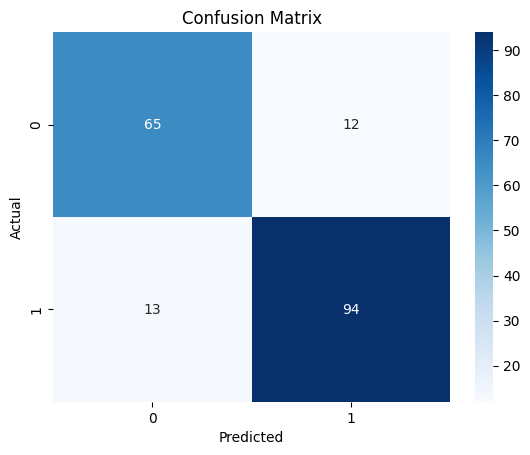

In [28]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig("confusion_matrix.png")

plt.show()

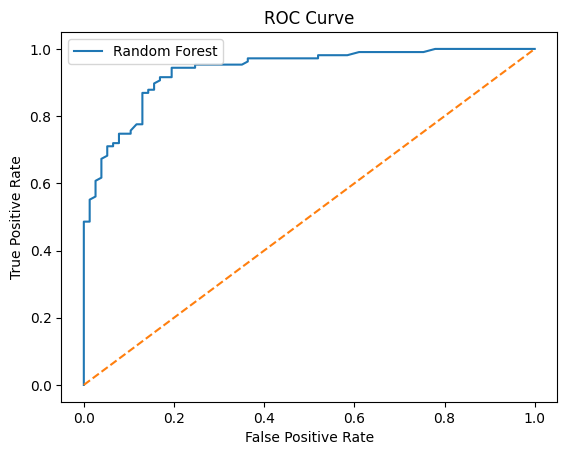

In [29]:
fpr, tpr, _ = roc_curve(y_test, rf_prob)

plt.plot(fpr, tpr, label="Random Forest")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.savefig("roc_curve.png")

plt.show()

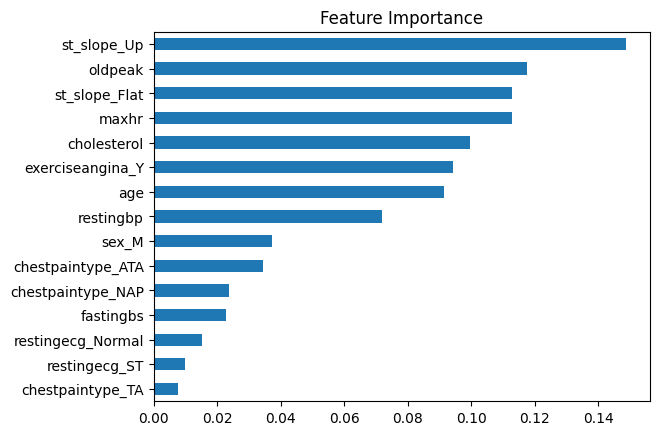

In [30]:
importance = rf.feature_importances_

features = X.columns

feature_importance = pd.Series(importance, index=features)

feature_importance.sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.savefig("feature_importance.png")

plt.show()

In [31]:
pickle.dump(rf, open("model.pkl","wb"))

pickle.dump(scaler, open("scaler.pkl","wb"))